In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast

In [2]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

path = '../dataset/ptb_xl/'
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass


In [3]:
def plot_ecg_12_leads(data_plot, data_label=['NORM']):
    plt.figure(figsize=(24,12))
    print(f"Class {data_label}")
    ecg_leads = {
        0: "I",
        1: "II",
        2: "III",
        3: "aVR",
        4: "aVL",
        5: "aVF",
        6: "V1",
        7: "V2",
        8: "V3",
        9: "V4",
        10: "V5",
        11: "V6"
    }
    for i in range(12):
        plt.subplot(4,3,i+1)
        plt.plot(data_plot[:, i])
        plt.title(f"Lead {ecg_leads[i]}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.grid(True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

In [4]:
print("Count number of classes of y_train")
counts = y_train.value_counts().sort_index()  # Sort by class label (0 → 4)
print(counts)

Count number of classes of y_train
diagnostic_superclass
[]                      371
[CD]                   1524
[CD, HYP]               273
[CD, MI, STTC]           97
[CD, MI, STTC, HYP]      92
[CD, STTC]              433
[CD, STTC, HYP]         186
[HYP]                   479
[MI]                   2276
[MI, CD]               1164
[MI, CD, HYP]           112
[MI, CD, STTC]          105
[MI, CD, STTC, HYP]      48
[MI, HYP]               166
[MI, STTC]              538
[MI, STTC, HYP]         320
[NORM]                 8157
[NORM, CD]              362
[NORM, CD, STTC]          5
[NORM, HYP]               2
[NORM, MI, CD, HYP]       1
[NORM, STTC]             24
[STTC]                 2158
[STTC, HYP]             708
Name: count, dtype: int64


In [5]:
print("Count number of classes of y_test")
counts = y_test.value_counts().sort_index()  # Sort by class label (0 → 4)
print(counts)

Count number of classes of y_test
diagnostic_superclass
[]                      40
[CD]                   184
[CD, HYP]               27
[CD, MI, STTC]           8
[CD, MI, STTC, HYP]     11
[CD, STTC]              38
[CD, STTC, HYP]         25
[HYP]                   56
[MI]                   256
[MI, CD]               133
[MI, CD, HYP]            5
[MI, CD, STTC]          13
[MI, CD, STTC, HYP]      5
[MI, HYP]               17
[MI, STTC]              61
[MI, STTC, HYP]         41
[NORM]                 912
[NORM, CD]              45
[NORM, CD, HYP]          2
[NORM, STTC]             4
[STTC]                 242
[STTC, HYP]             73
Name: count, dtype: int64


Class ['NORM']


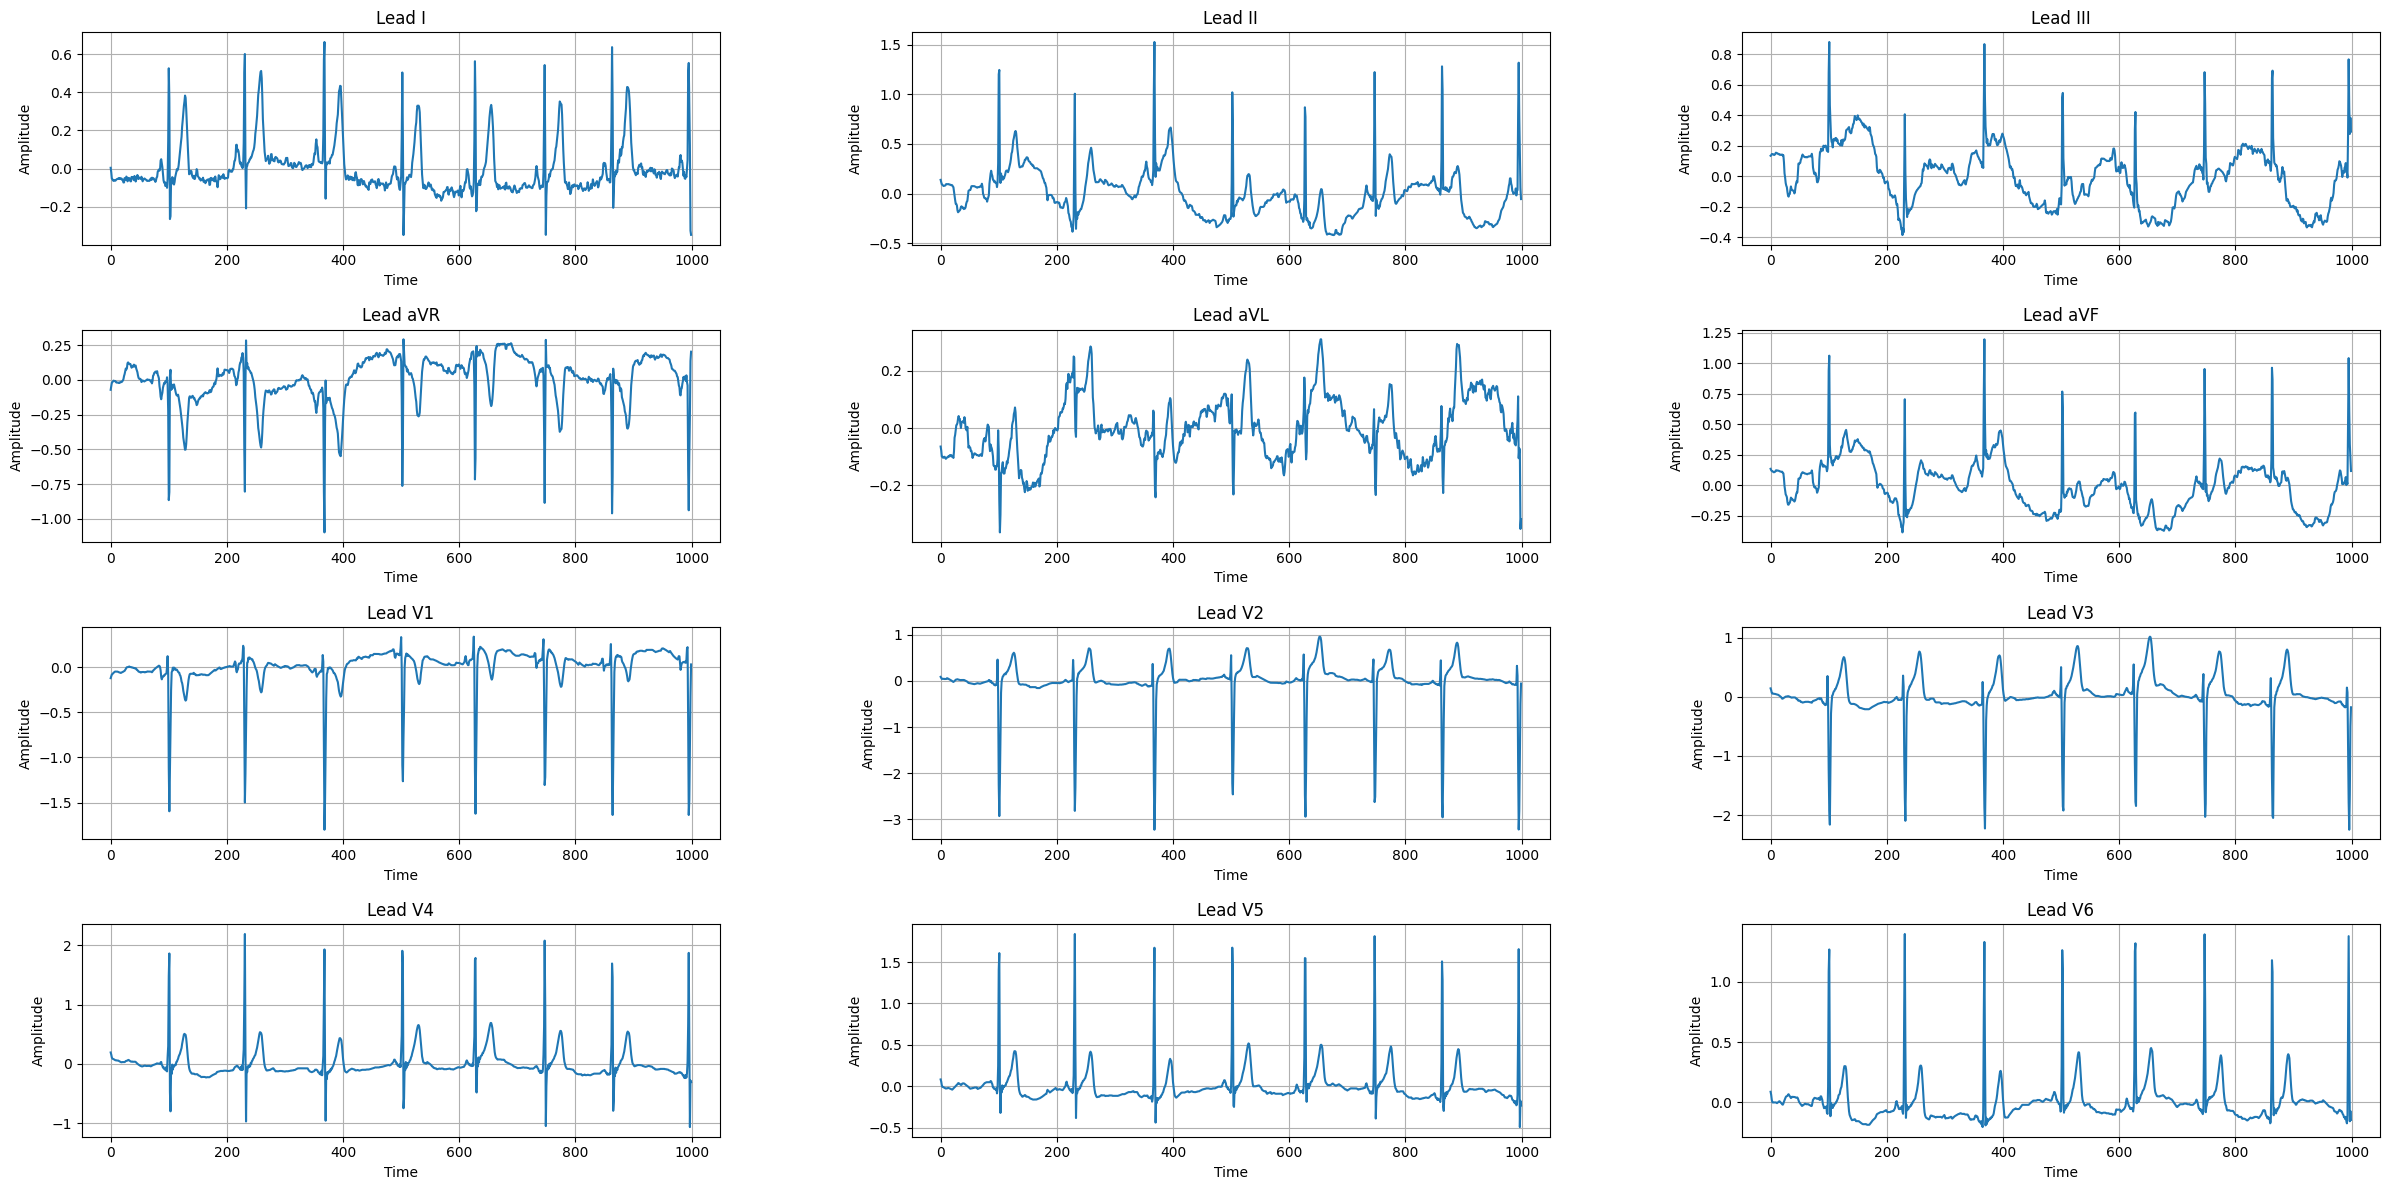

In [88]:
plot_ecg_12_leads(X_train[1, :], y_train[1])

In [64]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from math import gcd

def resample_signal_poly(original_signal, original_rate=100, target_rate=125):
    factor = gcd(original_rate, target_rate)
    up = target_rate //factor
    down = original_rate // factor
    return signal.resample_poly(original_signal, up, down)

##Pan tompkins
def pan_tompkins(ecg, fs):
    """
    Pan-Tompkins R-peak detection algorithm.
    ecg: 1D numpy array of raw ECG signal
    fs: Sampling frequency in Hz
    """
    
    # 1. Bandpass Filter (5-15 Hz)
    nyq = 0.5 * fs
    low = 5 / nyq
    high = 15 / nyq
    b, a = signal.butter(1, [low, high], btype='band')
    ecg_filtered = signal.filtfilt(b, a, ecg)
    
    # 2. Differentiation
    diff = np.ediff1d(ecg_filtered)
    
    # 3. Squaring
    squared = diff ** 2
    
    # 4. Moving Window Integration (≈150ms window)
    window_size = int(0.150 * fs)
    mwa = np.convolve(squared, np.ones(window_size) / window_size, mode='same')
    
    # 5. Adaptive Thresholding
    threshold = np.mean(mwa) * 1.2  # tweak this as needed
    peaks, _ = signal.find_peaks(mwa, height=threshold, distance=int(0.3 * fs))  # refractory period ≈300ms

    # 6. Refine R-peaks: Find max in original ECG near each mwa peak
    r_peaks = []
    search_window = int(0.1 * fs)  # ±100ms window
    for peak in peaks:
        start = max(peak - search_window, 0)
        end = min(peak + search_window, len(ecg))
        r_peak = start + np.argmax(ecg[start:end])
        r_peaks.append(r_peak)

    return np.array(r_peaks), mwa, ecg_filtered

##Extract beat
def extract_beats_from_r(ecg, r_peaks, fs, post_ms=400):
    post_samples = int(125)
    #post_samples = int((post_ms / 1000.0) * fs)
    beats = []

    for r in r_peaks:
        end = r + post_samples
        if end <= len(ecg):
            beat = ecg[r:end]
            beats.append(beat)

    return np.array(beats)

##Pad to beats 187
def pad_beats_to_187(beats, target_length=187):
    """
    Pads each beat with zeros at the end to reach target length.
    Input: beats = list or array of shape (num_beats, current_length)
    Output: padded_beats = array of shape (num_beats, target_length)
    """
    padded_beats = []

    for beat in beats:
        pad_width = target_length - len(beat)
        if pad_width > 0:
            beat_padded = np.pad(beat, (0, pad_width), mode='constant', constant_values=0)
        else:
            beat_padded = beat[:target_length]  # truncate if longer
        padded_beats.append(beat_padded)

    return np.array(padded_beats)

##Normalize
def normalize_min_max(beats):
    """
    Normalize ECG beats to the range [0, 1] using Min-Max normalization.
    Input: beats = numpy array of shape (num_beats, 187)
    Output: normalized_beats = Min-Max normalized ECG beats
    """
    # Min and Max for each beat
    min_vals = np.min(beats, axis=1, keepdims=True)
    max_vals = np.max(beats, axis=1, keepdims=True)
    
    # Normalize each beat (avoid division by zero if max equals min)
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1  # prevent division by zero
    
    normalized_beats = (beats - min_vals) / range_vals

    return normalized_beats

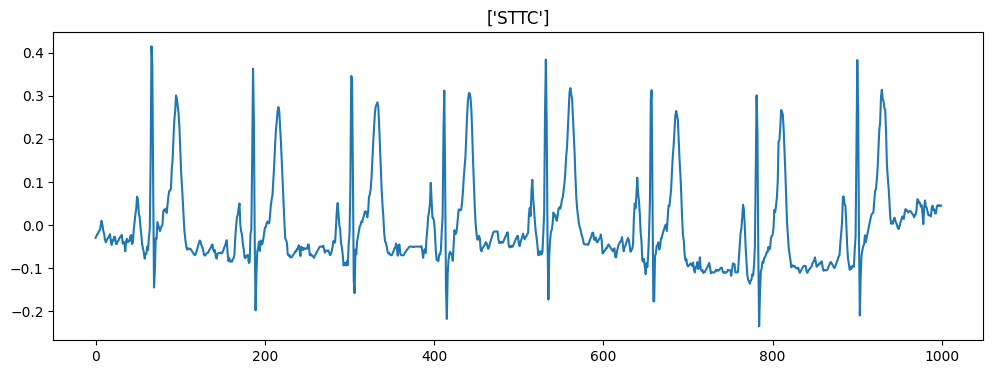

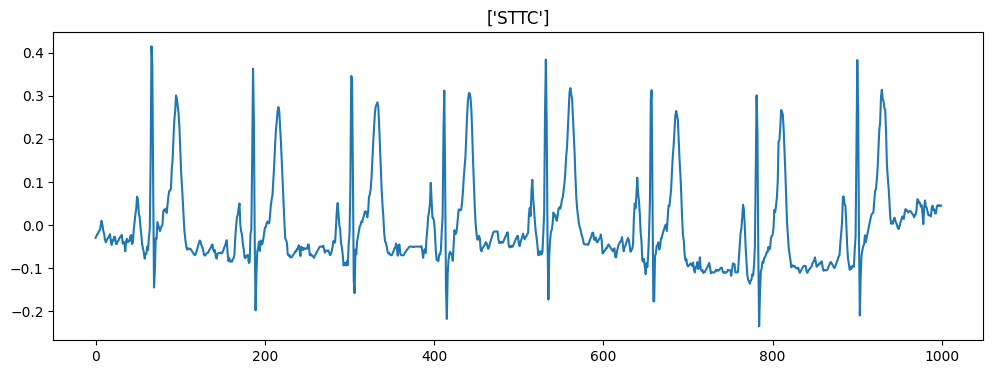

(7, 187)


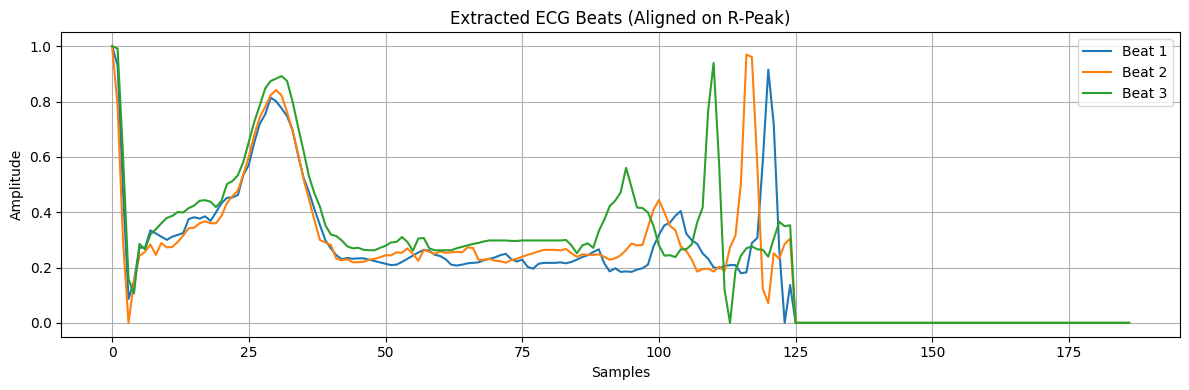

In [72]:
index = 54
ecg_, label_ = X_train[index, :, 1], y_train[index]
plt.figure(figsize=(12, 4))
plt.plot(ecg_)
plt.title(label_)
plt.show()
# Detect R-peaks
sampling_rate = 100
sampling_rate_new = 100
ecg_resampled = resample_signal_poly(ecg_, sampling_rate, sampling_rate_new)
plt.figure(figsize=(12, 4))
plt.plot(ecg_resampled)
plt.title(label_)
plt.show()
r_peaks, mwa, ecg_filtered = pan_tompkins(ecg_resampled, sampling_rate_new)
beats = extract_beats_from_r(ecg_resampled, r_peaks, sampling_rate_new)
normalize_beats = normalize_min_max(beats)
input_beats = pad_beats_to_187(normalize_beats)

print(input_beats.shape)  # (10, 187)

# Plot first 3 extracted beats
plt.figure(figsize=(12, 4))
for i in range(min(3, len(input_beats))):
    plt.plot(input_beats[i], label=f'Beat {i+1}')
plt.title("Extracted ECG Beats (Aligned on R-Peak)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Plot result
# plt.figure(figsize=(12, 6))
# plt.plot(ecg_, label='Raw ECG', alpha=0.5)
# plt.plot(ecg_filtered, label='Filtered ECG')
# plt.plot(r_peaks, ecg_[r_peaks], 'ro', label='R-peaks')
# plt.title('ECG with Detected R-peaks (Pan-Tompkins)')
# plt.legend()
# plt.xlabel('Samples')
# plt.ylabel('Amplitude')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RCNN_LSTM(nn.Module):
    def __init__(self, input_size=187, num_classes=5):
        super(RCNN_LSTM, self).__init__()

        self.conv1_1 = nn.Conv1d(in_channels=1, out_channels=48, kernel_size=6, padding='same')
        self.bn1_1 = nn.BatchNorm1d(48)

        self.conv1_2 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_2 = nn.BatchNorm1d(64)

        self.conv1_3 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_3 = nn.BatchNorm1d(32)

        self.lstm1 = nn.LSTM(input_size=32, hidden_size=32, batch_first=True, bidirectional=False)
        self.residual_1 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_1 = nn.BatchNorm1d(16)

        self.conv1_4 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_4 = nn.BatchNorm1d(64)

        self.conv1_5 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_5 = nn.BatchNorm1d(32)

        self.lstm2 = nn.LSTM(input_size=32, hidden_size=32, batch_first=True, bidirectional=False)
        self.residual_2 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_2 = nn.BatchNorm1d(16)

        self.conv1_6 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_6 = nn.BatchNorm1d(64)

        self.conv1_7 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_7 = nn.BatchNorm1d(32)

        self.lstm3 = nn.LSTM(input_size=32, hidden_size=32, batch_first=True, bidirectional=False)
        self.residual_3 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_3 = nn.BatchNorm1d(16)

        self.conv1_8 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_8 = nn.BatchNorm1d(64)

        self.conv1_9 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_9 = nn.BatchNorm1d(32)

        self.lstm4 = nn.LSTM(input_size=32, hidden_size=32, batch_first=True, bidirectional=False)
        self.residual_4 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_4 = nn.BatchNorm1d(16)

        dummy_input = torch.zeros(1, 1, input_size)
        dummy_output = self._forward_convs(dummy_input)
        flattened_size = dummy_output.numel()

        self.fc1 = nn.Linear(flattened_size, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, num_classes)

    def _forward_convs(self, x):
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = F.relu(self.bn1_3(self.conv1_3(x)))

        x_lstm, _ = self.lstm1(x.permute(0, 2, 1))
        x_lstm = x_lstm.permute(0, 2, 1)
        residual_1 = self.bn_residual_1(self.residual_1(x))
        x = F.relu(torch.cat((x_lstm, residual_1), dim=1))
        x = F.max_pool1d(x, 6, padding=3)

        x = F.relu(self.bn1_4(self.conv1_4(x)))
        x = F.relu(self.bn1_5(self.conv1_5(x)))

        x_lstm, _ = self.lstm2(x.permute(0, 2, 1))
        x_lstm = x_lstm.permute(0, 2, 1)
        residual_2 = self.bn_residual_2(self.residual_2(x))
        x = F.relu(torch.cat((x_lstm, residual_2), dim=1))
        x = F.max_pool1d(x, 6, stride=2, padding=3)

        x = F.relu(self.bn1_6(self.conv1_6(x)))
        x = F.relu(self.bn1_7(self.conv1_7(x)))

        x_lstm, _ = self.lstm3(x.permute(0, 2, 1))
        x_lstm = x_lstm.permute(0, 2, 1)
        residual_3 = self.bn_residual_3(self.residual_3(x))
        x = F.relu(torch.cat((x_lstm, residual_3), dim=1))
        x = F.max_pool1d(x, 6, padding=3)

        x = F.relu(self.bn1_8(self.conv1_8(x)))
        x = F.relu(self.bn1_9(self.conv1_9(x)))

        x_lstm, _ = self.lstm4(x.permute(0, 2, 1))
        x_lstm = x_lstm.permute(0, 2, 1)
        residual_4 = self.bn_residual_4(self.residual_4(x))
        x = F.relu(torch.cat((x_lstm, residual_4), dim=1))
        x = F.max_pool1d(x, 6, padding=3)

        return x

    def forward(self, x):
        x = self._forward_convs(x)
        flat = x.view(x.size(0), -1)
        x = F.relu(self.fc1(flat))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [74]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RCNN_LSTM().to(device)
model.load_state_dict(torch.load('../train_models/models_save/CNN_Resnet_LSTM.pth'))
model.eval()

/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv1d(


RCNN_LSTM(
  (conv1_1): Conv1d(1, 48, kernel_size=(6,), stride=(1,), padding=same)
  (bn1_1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_2): Conv1d(48, 64, kernel_size=(6,), stride=(1,), padding=same)
  (bn1_2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_3): Conv1d(64, 32, kernel_size=(6,), stride=(1,), padding=same)
  (bn1_3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lstm1): LSTM(32, 32, batch_first=True)
  (residual_1): Conv1d(32, 16, kernel_size=(16,), stride=(1,), padding=same)
  (bn_residual_1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_4): Conv1d(48, 64, kernel_size=(6,), stride=(1,), padding=same)
  (bn1_4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_5): Conv1d(64, 32, kernel_size=(6,), stride=(1,), padding=same)
  (bn1_5): BatchNorm1d(32, eps=1e-05, momen

In [75]:
def plot_prediction(input,output):
    label_map = {0: 'N', 1: 'S', 2: 'P', 3: 'F', 4: 'U'}
    input_np = input.detach().squeeze().cpu().numpy()
    output_np = output.detach().squeeze().cpu().numpy()
    plt.figure(figsize=(24,12))
    for i in range(len(input_np)):
        plt.subplot(4,4,i+1)
        plt.plot(input_np[i])
        plt.title(f"Prediction {label_map[output_np[i]]}")
        plt.grid(True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

Class ['NORM']


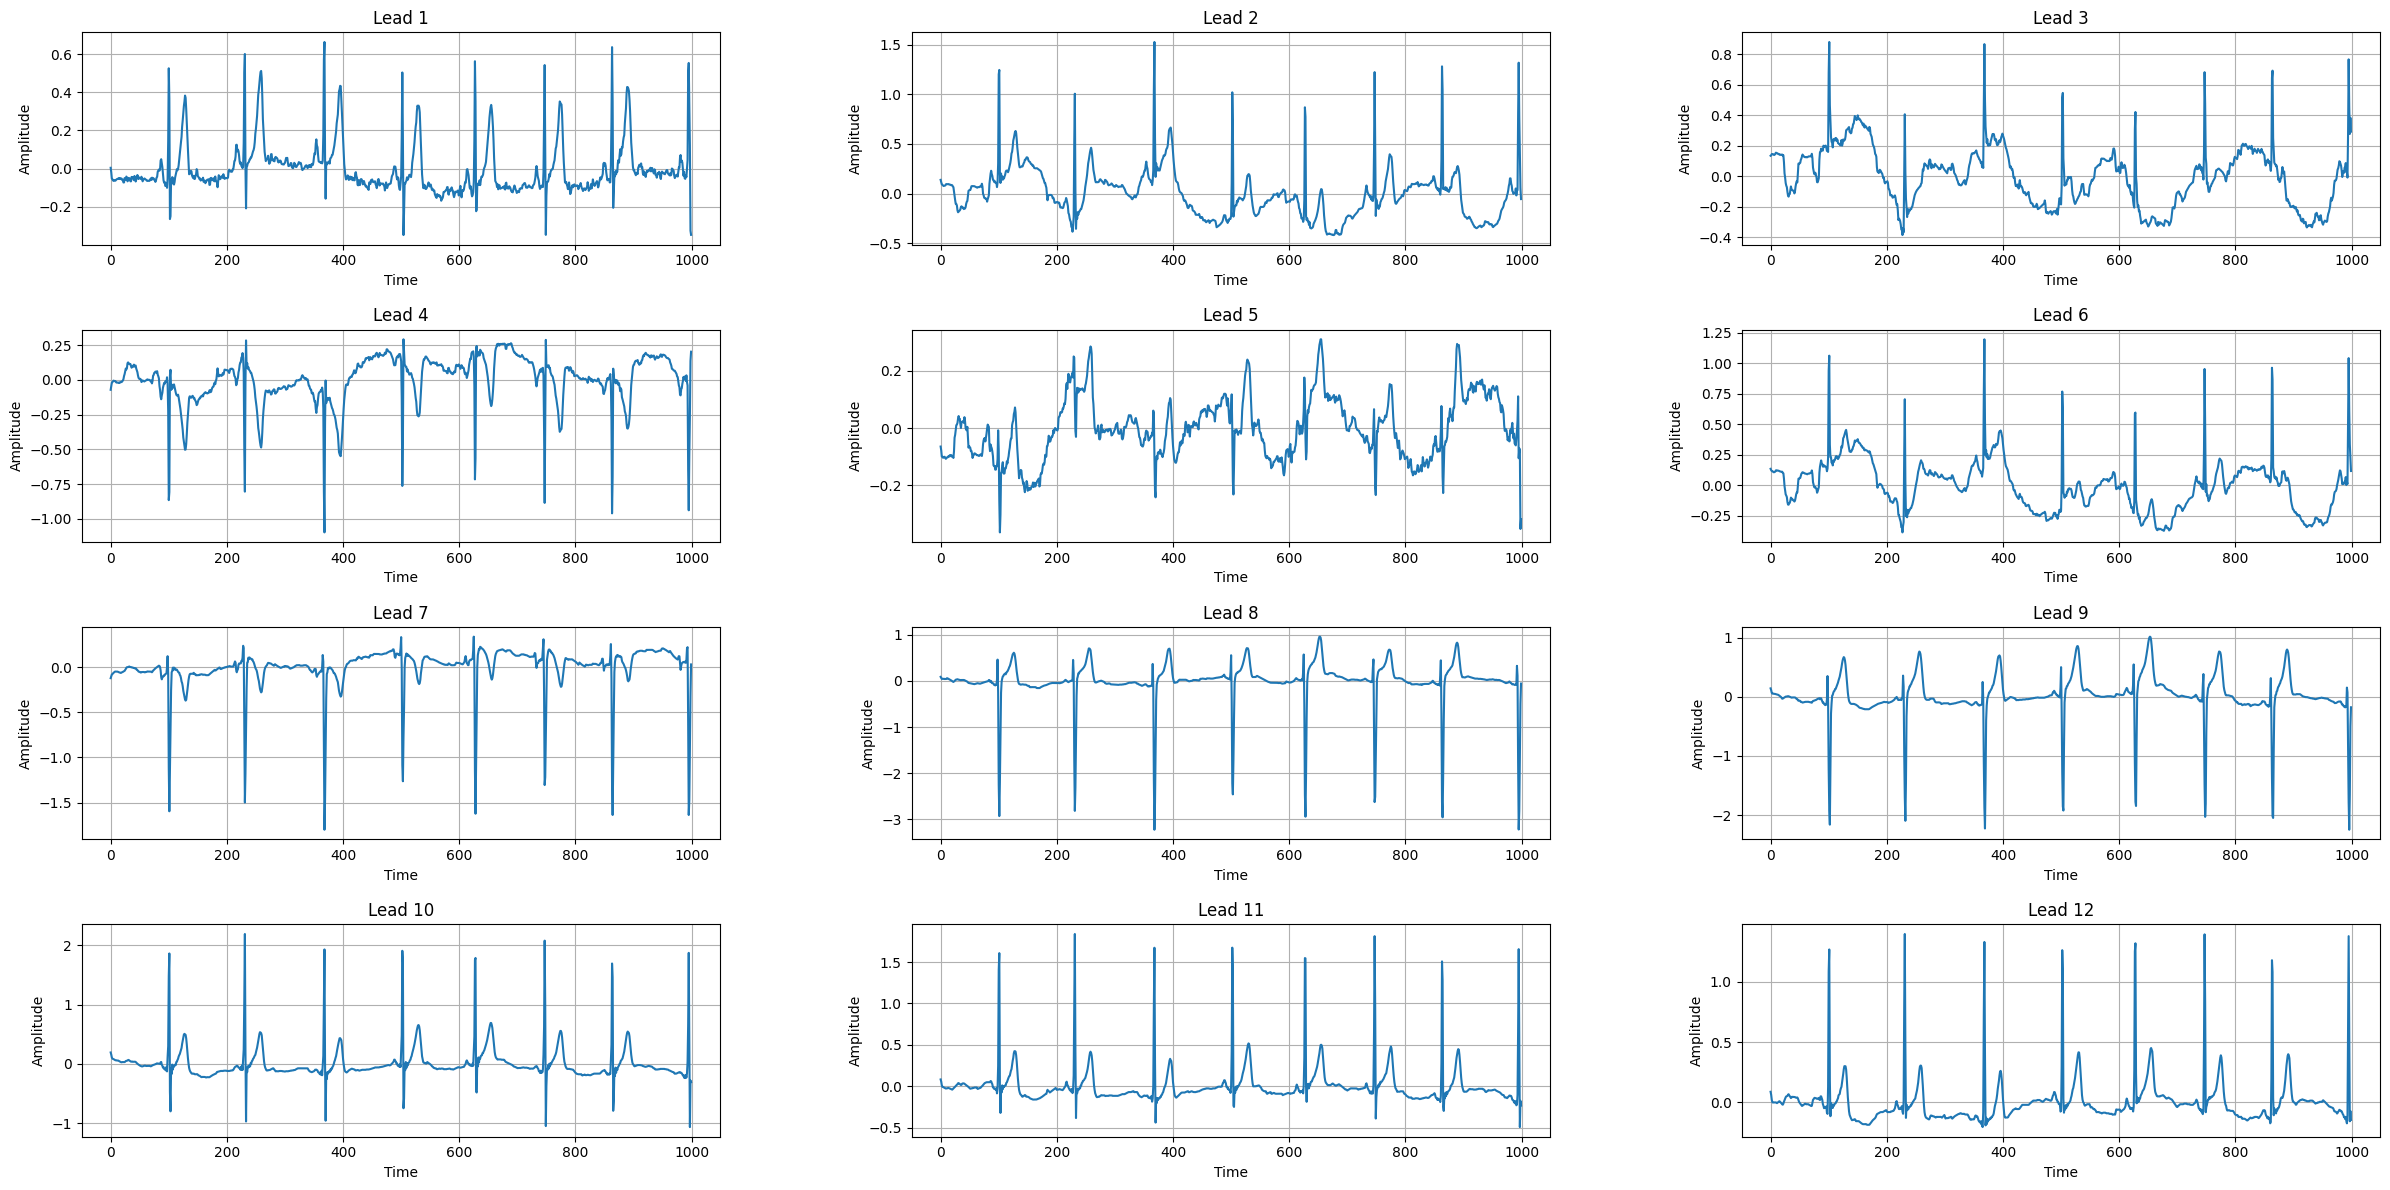

In [84]:
plot_ecg_12_leads(X_train[1, :], y_train[1])

Class ['CD', 'HYP']


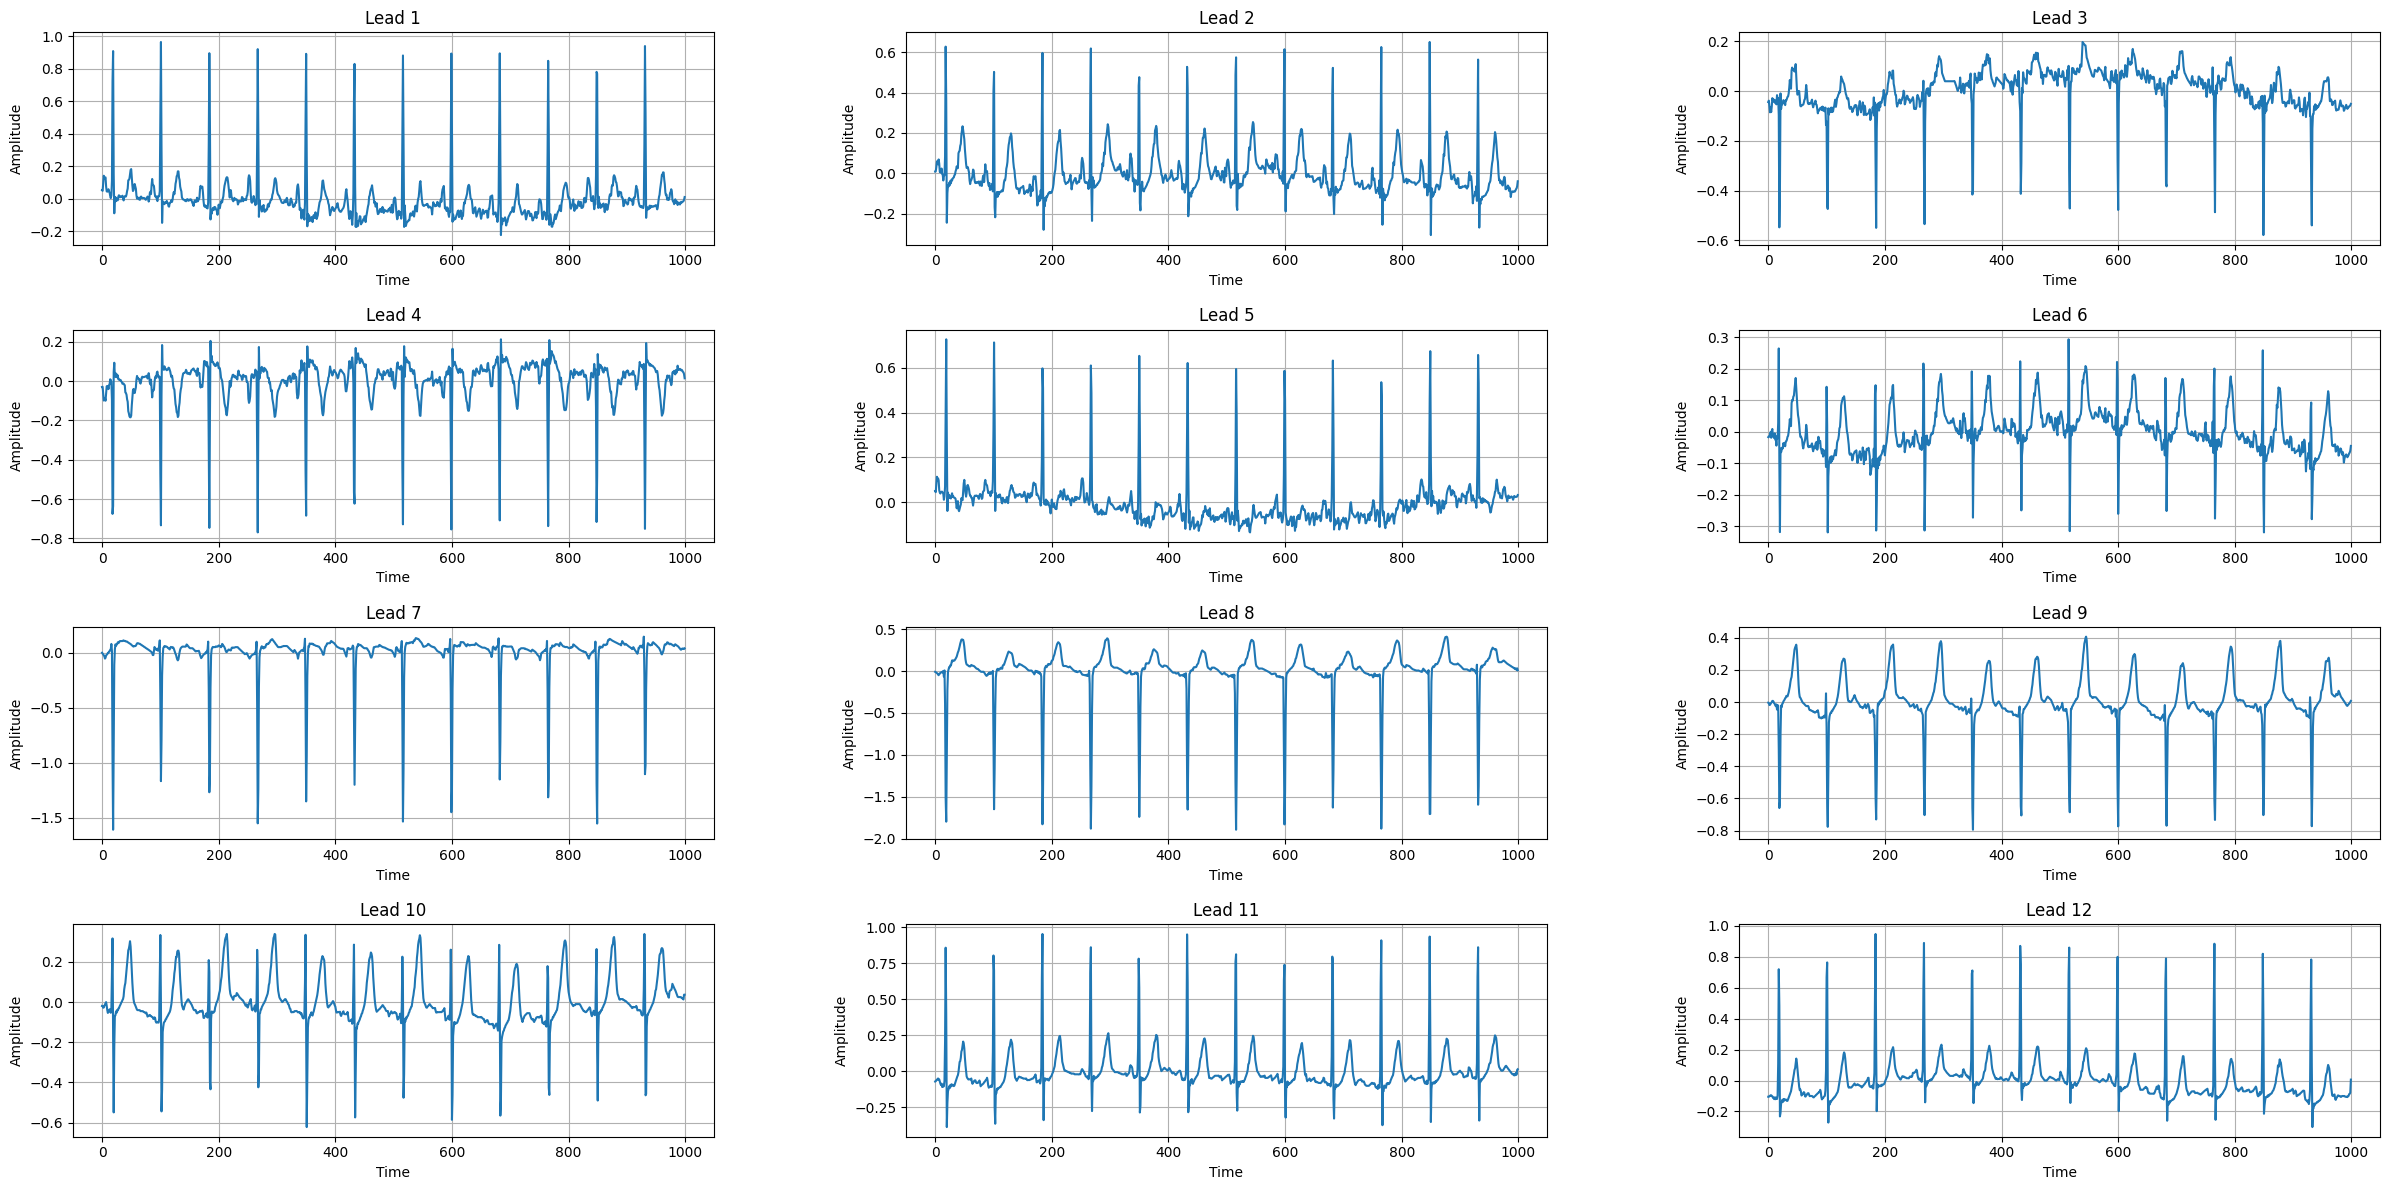

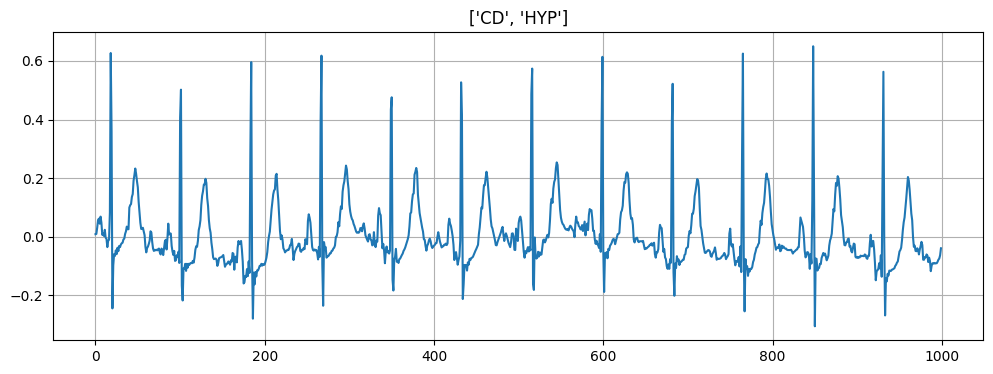

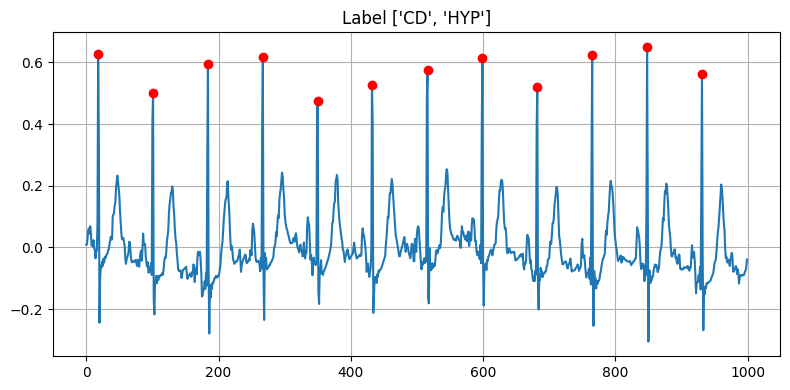

tensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1], device='cuda:0')


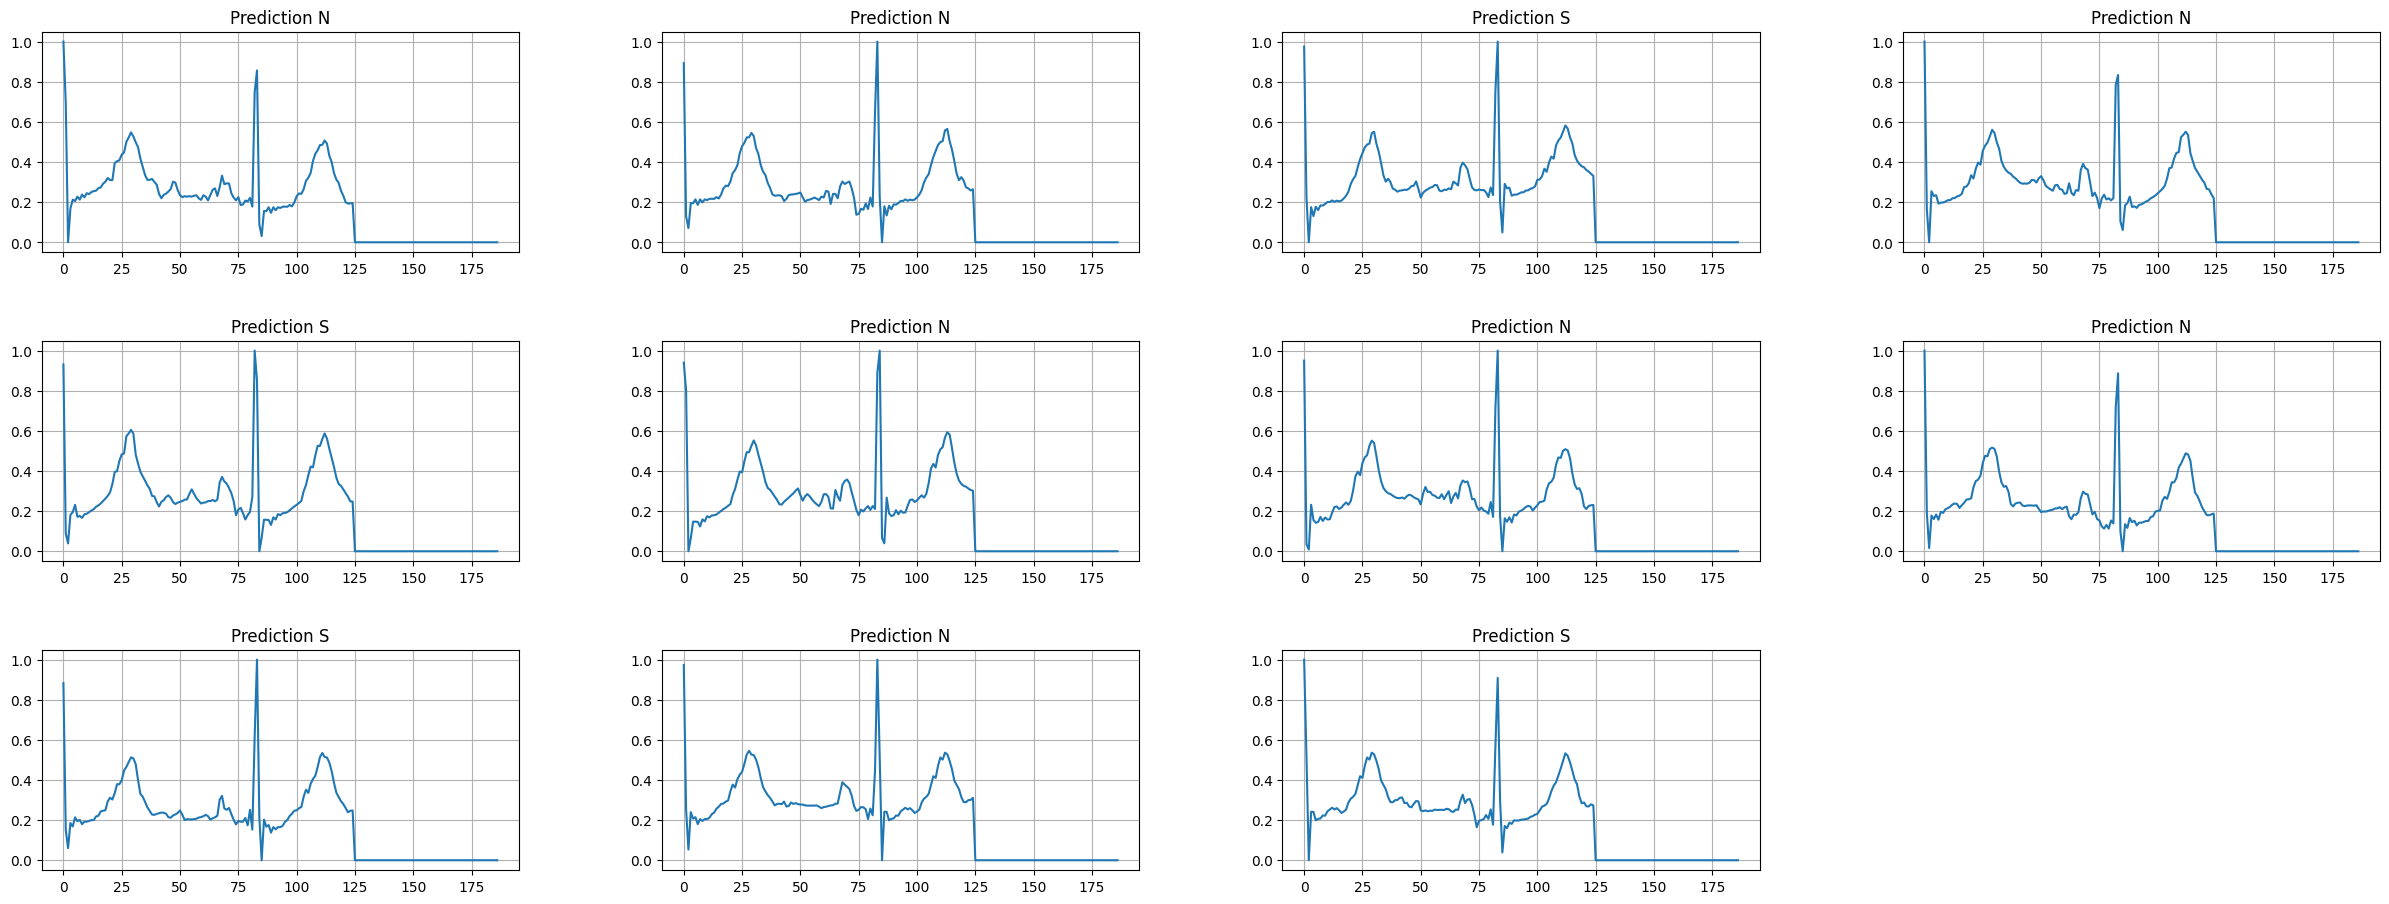

In [ ]:
index = 12341
ecg_, label_ = X_train[index, :, 1], y_train[index]
plot_ecg_12_leads(X_train[index, :], y_train[index])
sampling_rate = 100
sampling_rate_new = 100
ecg_resampled = resample_signal_poly(ecg_, sampling_rate, sampling_rate_new)
plt.figure(figsize=(12, 4))
plt.plot(ecg_resampled)
plt.title(label_)
plt.grid("on")
plt.show()
r_peaks, mwa, ecg_filtered = pan_tompkins(ecg_resampled, sampling_rate_new)
beats = extract_beats_from_r(ecg_resampled, r_peaks, sampling_rate_new)
normalize_beats = normalize_min_max(beats)
input_beats = pad_beats_to_187(normalize_beats)

plt.figure(figsize=(8,4))
plt.plot(ecg_resampled)
plt.plot(r_peaks, ecg_resampled[r_peaks], 'ro', label='R-peaks')
plt.title(f"Label {label_}")
plt.tight_layout()
plt.grid(True)
plt.show()

input_data = torch.from_numpy(input_beats).float().unsqueeze(1).to(device)
with torch.no_grad():  # Turn off gradient tracking for inference
    output = model(input_data)
    labels = torch.argmax(output, dim=1)
print(labels)
plot_prediction(input_data, labels)